<a href="https://colab.research.google.com/github/GameofCodeZ/Karate-club-assignment-/blob/main/Aes_Avalanche_effect_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
pip install pycryptodome

In [16]:
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import random



AES requires plaintext length to be multiple of 16 bytes

In [17]:
def pad(text):
    while len(text) % 16 != 0:
        text += " "
    return text

 Encrypt plaintext using AES

In [18]:
def encrypt(plaintext, key):
    cipher = AES.new(key, AES.MODE_ECB)
    ciphertext = cipher.encrypt(plaintext.encode())
    return ciphertext

Convert bytes to binary string


In [19]:
def bytes_to_binary(data):
    return ''.join(format(byte, '08b') for byte in data)

Flip one random bit in plaintext

In [23]:
def flip_one_bit(text):
    byte_array = bytearray(text.encode())

    byte_index = random.randint(0, len(byte_array) - 1)
    bit_index = random.randint(0, 7)

    byte_array[byte_index] ^= (1 << bit_index)

    return byte_array.decode('latin1')

Count differing bits


In [24]:
def count_bit_difference(bin1, bin2):
    diff = 0
    for b1, b2 in zip(bin1, bin2):
        if b1 != b2:
            diff += 1
    return diff

###Running the Avalanche Effect Experiment

We now perform the experiment:

1. Generate a random AES key  
2. Encrypt the plaintext  
3. Modify one bit of plaintext  
4. Encrypt again  
5. Compare ciphertexts  
6. Calculate the avalanche percentage

In [25]:
key = get_random_bytes(16)

plaintext = "HelloWorld123456"
plaintext = pad(plaintext)

print("Original Plaintext:", plaintext)

trials = 10
results = []

for i in range(trials):

    modified_plaintext = pad(flip_one_bit(plaintext))

    ct1 = encrypt(plaintext, key)
    ct2 = encrypt(modified_plaintext, key)

    bin1 = bytes_to_binary(ct1)
    bin2 = bytes_to_binary(ct2)

    changed_bits = count_bit_difference(bin1, bin2)
    avalanche = (changed_bits / len(bin1)) * 100

    results.append(avalanche)

    print(f"\nTrial {i+1}")
    print("Modified Plaintext:", modified_plaintext)
    print("Bits Changed:", changed_bits)
    print("Avalanche Effect:", round(avalanche,2), "%")


avg = sum(results)/len(results)

print("\nAverage Avalanche Effect:", round(avg,2), "%")

Original Plaintext: HelloWorld123456

Trial 1
Modified Plaintext: HelloWorld122456
Bits Changed: 63
Avalanche Effect: 49.22 %

Trial 2
Modified Plaintext: HelloWmrld123456
Bits Changed: 70
Avalanche Effect: 54.69 %

Trial 3
Modified Plaintext: HelloWorld103456
Bits Changed: 65
Avalanche Effect: 50.78 %

Trial 4
Modified Plaintext: HelloWorldq23456
Bits Changed: 54
Avalanche Effect: 42.19 %

Trial 5
Modified Plaintext: HelloWmrld123456
Bits Changed: 70
Avalanche Effect: 54.69 %

Trial 6
Modified Plaintext: HelloWorlf123456
Bits Changed: 73
Avalanche Effect: 57.03 %

Trial 7
Modified Plaintext: HelloWorlf123456
Bits Changed: 73
Avalanche Effect: 57.03 %

Trial 8
Modified Plaintext: HelloWorld12345v
Bits Changed: 74
Avalanche Effect: 57.81 %

Trial 9
Modified Plaintext: HelmoWorld123456
Bits Changed: 58
Avalanche Effect: 45.31 %

Trial 10
Modified Plaintext: HenloWorld123456
Bits Changed: 62
Avalanche Effect: 48.44 %

Average Avalanche Effect: 51.72 %


## Visualization of Avalanche Effect

To better analyze the avalanche effect, we visualize the percentage of changed ciphertext bits across multiple trials.

A strong cryptographic algorithm should produce an avalanche effect close to **50%**, indicating good diffusion.

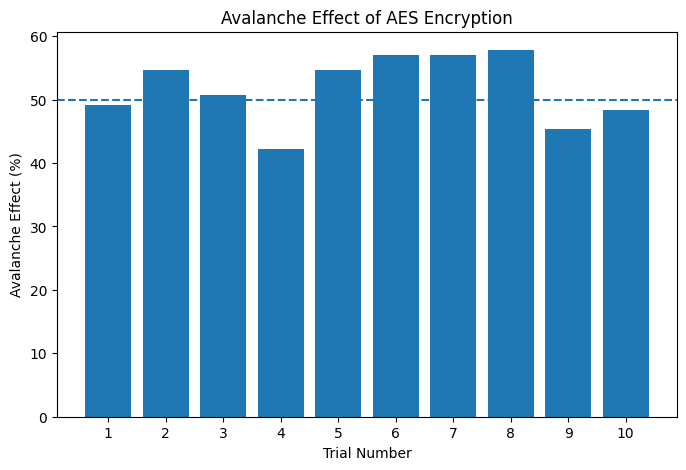

In [26]:
import matplotlib.pyplot as plt

# Create trial numbers
trials_list = list(range(1, len(results)+1))

plt.figure(figsize=(8,5))
plt.bar(trials_list, results)

plt.axhline(50, linestyle='--')

plt.xlabel("Trial Number")
plt.ylabel("Avalanche Effect (%)")
plt.title("Avalanche Effect of AES Encryption")
plt.xticks(trials_list)

plt.show()